In [1]:
from datasets import load_dataset

ds = load_dataset("changelinglab/easycall-dysarthria")

In [2]:
severity1 = ds["train"].filter(
    lambda x: x["dysarthria_severity"] == "1"
)

In [3]:
print(len(severity1))

3588


In [4]:
from collections import Counter

commands = Counter(severity1["text"])

print("Unique commands:", len(commands))
print(commands)

Unique commands: 71
Counter({'uno': 53, 'rubrica': 53, 'rimuovi': 53, 'vai nel registro chiamate': 53, 'salva': 53, 'chiudi rubrica': 53, 'si': 53, 'nave': 53, 'muovi': 53, 'chiama ultimo numero': 53, 'sei': 53, 'apri': 53, 'sotto': 53, 'aggiungi ai preferiti': 53, 'zelo': 53, 'scendi': 53, 'vai alla tastiera': 53, 'disattiva vivavoce': 53, 'raggiungi': 53, 'tra': 53, 'chiudi applicazione': 53, 'bue': 53, 'cancella tutto': 53, 'termina chiamata': 53, 'aggiungi': 53, 'scorri verso il basso': 53, 'quattro': 53, 'cancella contatto': 53, 'no': 53, 'nove': 53, 'seleziona': 53, 'richiama': 53, 'fai una telefonata': 53, 'deseleziona': 53, 'chiama': 53, 'sopra': 53, 'sette': 53, 'nuovo contatto': 53, 'chiudi': 53, 'vai alla pagina principale': 53, 'zero': 53, 'stop': 53, 'due': 53, 'vivavoce': 53, 'tre': 53, 'cinque': 53, 'scesi': 53, 'cancella': 53, 'chiama emergenza': 53, 'preferiti': 53, 'sali': 53, 'top': 53, 'indietro': 53, 'otto': 53, 'attiva vivavoce': 53, 'muto': 53, 'terminare': 53, '

In [5]:
import whisper
import torch

model = whisper.load_model("turbo")

print("Model loaded")

Model loaded


In [6]:
from collections import defaultdict

command_samples = defaultdict(list)

for sample in severity1:
    command = sample["text"]
    command_samples[command].append(sample)

print("Commands collected:", len(command_samples))

Commands collected: 71


In [7]:
from collections import defaultdict
import re
import numpy as np

command_transcripts = defaultdict(list)

for command, samples in command_samples.items():

    for sample in samples:

        audio = sample["audio"]["array"].astype(np.float32)

        result = model.transcribe(
            audio,
            language="it",
            task="transcribe"
        )

        pred = result["text"].lower().strip()

        # normalize
        pred = re.sub(r"[^\w\s]", "", pred)

        command_transcripts[command].append(pred)

print("ASR inference completed.")

ASR inference completed.


In [8]:
cmd = "rubrica"

for t in command_transcripts[cmd][:15]:
    print(t)

grazie
buon appetito
rubrica
allo meriter
hahaha
rubrica
no baby
блиitius
comandante induzione
andate
buon appetito
 gettelo
f andarate
boyca
alla bonita


consistency = frequency of most common transcript / total samples

In [9]:
from collections import Counter

command_consistency = {}

for command, transcripts in command_transcripts.items():

    counts = Counter(transcripts)

    top_transcript, top_count = counts.most_common(1)[0]

    score = top_count / len(transcripts)

    command_consistency[command] = {
        "score": score,
        "top_transcript": top_transcript,
        "top_count": top_count,
        "total": len(transcripts)
    }

In [10]:
sorted_commands = sorted(
    command_consistency.items(),
    key=lambda x: x[1]["score"],
    reverse=True
)

for cmd, info in sorted_commands[:20]:
    print(cmd, "->", info)

cella -> {'score': 0.6226415094339622, 'top_transcript': 'ciao', 'top_count': 33, 'total': 53}
salva -> {'score': 0.5849056603773585, 'top_transcript': 'ciao', 'top_count': 31, 'total': 53}
sali -> {'score': 0.5849056603773585, 'top_transcript': 'ciao', 'top_count': 31, 'total': 53}
sei -> {'score': 0.4716981132075472, 'top_transcript': 'ciao', 'top_count': 25, 'total': 53}
no -> {'score': 0.4716981132075472, 'top_transcript': 'no', 'top_count': 25, 'total': 53}
si -> {'score': 0.32075471698113206, 'top_transcript': 'oh', 'top_count': 17, 'total': 53}
nove -> {'score': 0.3018867924528302, 'top_transcript': 'noi', 'top_count': 16, 'total': 53}
fai una telefonata -> {'score': 0.3018867924528302, 'top_transcript': 'grazie a tutti', 'top_count': 16, 'total': 53}
tre -> {'score': 0.2830188679245283, 'top_transcript': 'ah', 'top_count': 15, 'total': 53}
cinque -> {'score': 0.2830188679245283, 'top_transcript': 'grazie', 'top_count': 15, 'total': 53}
chiama -> {'score': 0.2641509433962264, 't

In [11]:
import pandas as pd

rows = []

for cmd, info in command_consistency.items():

    rows.append({
        "command": cmd,
        "consistency": info["score"],
        "top_transcript": info["top_transcript"],
        "samples": info["total"]
    })

df = pd.DataFrame(rows)

df = df.sort_values("consistency", ascending=False)

df.head(20)

,command,consistency,top_transcript,samples
65,cella,0.622642,ciao,53
52,sali,0.584906,ciao,53
4,salva,0.584906,ciao,53
30,no,0.471698,no,53
10,sei,0.471698,ciao,53
6,si,0.320755,oh,53
31,nove,0.301887,noi,53
34,fai una telefonata,0.301887,grazie a tutti,53
46,tre,0.283019,ah,53
47,cinque,0.283019,grazie,53


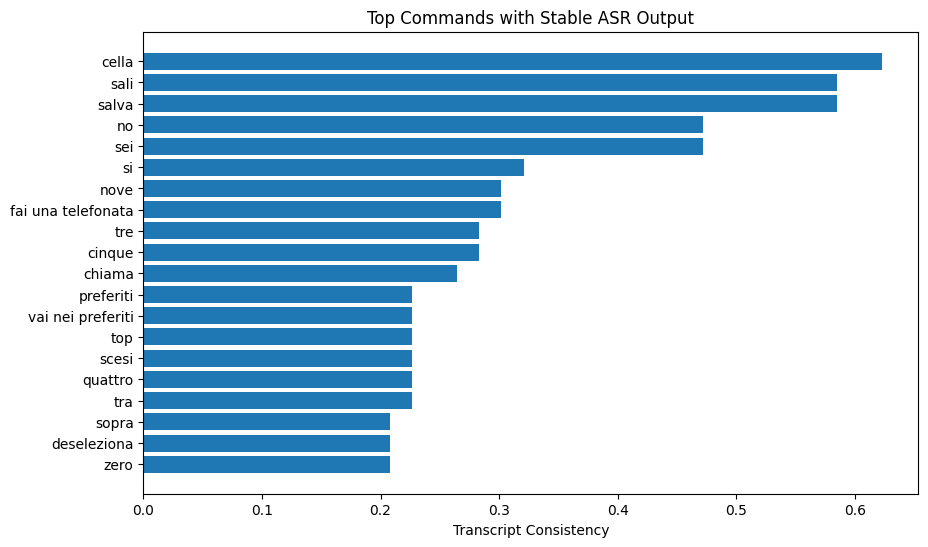

In [12]:
import matplotlib.pyplot as plt

top_df = df.head(20)

plt.figure(figsize=(10,6))

plt.barh(top_df["command"], top_df["consistency"])

plt.xlabel("Transcript Consistency")
plt.title("Top Commands with Stable ASR Output")

plt.gca().invert_yaxis()

plt.show()

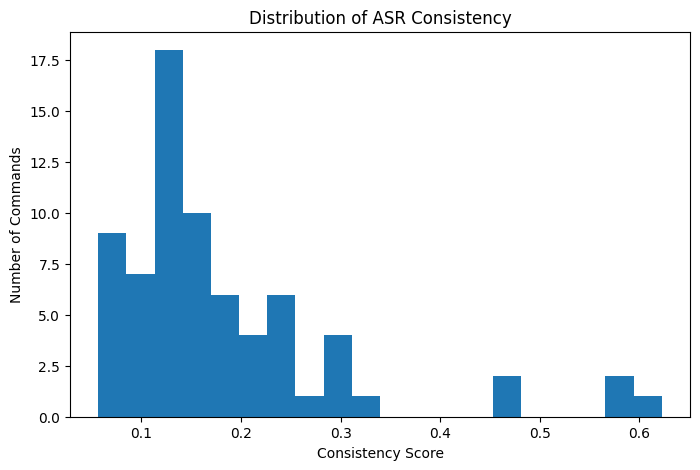

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["consistency"], bins=20)

plt.xlabel("Consistency Score")
plt.ylabel("Number of Commands")

plt.title("Distribution of ASR Consistency")

plt.show()

In [14]:
mvp_commands = df[df["consistency"] >= 0.30]

print("MVP command candidates:", len(mvp_commands))

mvp_commands

MVP command candidates: 8


,command,consistency,top_transcript,samples
65,cella,0.622642,ciao,53
52,sali,0.584906,ciao,53
4,salva,0.584906,ciao,53
30,no,0.471698,no,53
10,sei,0.471698,ciao,53
6,si,0.320755,oh,53
31,nove,0.301887,noi,53
34,fai una telefonata,0.301887,grazie a tutti,53


In [16]:
cmd = mvp_commands.iloc[0]["command"]

print("Command:", cmd)

Counter(command_transcripts[cmd]).most_common(10)

Command: cella


[('ciao', 33),
 ('grazie a tutti', 2),
 ('ok', 2),
 ('ciao a tutti', 2),
 ('allora', 1),
 ('voila', 1),
 ('parà', 1),
 ('momen', 1),
 ('oh', 1),
 ('ciao no', 1)]

In [17]:
import math
from collections import Counter

command_entropy = {}

for command, transcripts in command_transcripts.items():

    counts = Counter(transcripts)
    total = len(transcripts)

    entropy = 0

    for c in counts.values():
        p = c / total
        entropy -= p * math.log2(p)

    command_entropy[command] = entropy

In [18]:
df["entropy"] = df["command"].map(command_entropy)

df = df.sort_values(["consistency","entropy"], ascending=[False, True])

df.head(20)

,command,consistency,top_transcript,samples,entropy
65,cella,0.622642,ciao,53,2.473864
4,salva,0.584906,ciao,53,2.551789
52,sali,0.584906,ciao,53,2.627261
30,no,0.471698,no,53,2.574789
10,sei,0.471698,ciao,53,3.041863
6,si,0.320755,oh,53,3.250990
31,nove,0.301887,noi,53,3.925849
34,fai una telefonata,0.301887,grazie a tutti,53,4.482637
46,tre,0.283019,ah,53,3.611841
47,cinque,0.283019,grazie,53,4.062735


In [19]:
from collections import Counter

all_transcripts = []

for t in command_transcripts.values():
    all_transcripts.extend(t)

Counter(all_transcripts).most_common(20)

[('ciao', 305),
 ('grazie', 279),
 ('grazie a tutti', 278),
 ('no', 68),
 ('oh', 60),
 ('noi', 49),
 ('sì', 40),
 ('ciao a tutti', 38),
 ('ah', 31),
 ('a', 28),
 ('ok', 28),
 ('allora', 27),
 ('a presto', 25),
 ('', 23),
 ('ciao ciao', 22),
 ('stop', 16),
 ('wow', 12),
 ('4', 12),
 ('quattro', 12),
 ('alla', 11)]

In [20]:
for cmd, info in sorted_commands[:10]:
    print("\nCOMMAND:", cmd)
    print(Counter(command_transcripts[cmd]).most_common(5))


COMMAND: cella
[('ciao', 33), ('grazie a tutti', 2), ('ok', 2), ('ciao a tutti', 2), ('allora', 1)]

COMMAND: salva
[('ciao', 31), ('ciao a tutti', 4), ('bye bye', 3), ('grazie', 2), ('samo', 1)]

COMMAND: sali
[('ciao', 31), ('sali', 3), ('sì', 2), ('grazie a tutti', 2), ('fai', 2)]

COMMAND: sei
[('ciao', 25), ('hai', 4), ('sì', 3), ('oh', 3), ('ok', 3)]

COMMAND: no
[('no', 25), ('grazie', 12), ('ciao', 4), ('la', 1), ('burbare', 1)]

COMMAND: si
[('oh', 17), ('sì', 9), ('grazie', 7), ('ho', 5), ('ciao', 2)]

COMMAND: nove
[('noi', 16), ('ciao', 6), ('no', 4), ('ciao a tutti', 2), ('novi', 2)]

COMMAND: fai una telefonata
[('grazie a tutti', 16), ('ciao a tutti', 2), ('fai un teleponata', 1), ('vai un mitenti per parte', 1), ('mi elevena è lady panata', 1)]

COMMAND: tre
[('ah', 15), ('oh', 9), ('grazie', 6), ('no', 3), ('ciao', 3)]

COMMAND: cinque
[('grazie', 15), ('grazie a tutti', 7), ('5', 4), ('cinque', 2), ('cine', 1)]


In [21]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
import numpy as np

command_embeddings = {}

for command, transcripts in command_transcripts.items():

    emb = embedder.encode(transcripts)

    command_embeddings[command] = emb

In [23]:
command_centroids = {}

for cmd, emb in command_embeddings.items():

    centroid = np.mean(emb, axis=0)

    command_centroids[cmd] = centroid

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

separability_scores = {}

for cmd1, c1 in command_centroids.items():

    similarities = []

    for cmd2, c2 in command_centroids.items():

        if cmd1 == cmd2:
            continue

        sim = cosine_similarity([c1],[c2])[0][0]
        similarities.append(sim)

    separability_scores[cmd1] = 1 - max(similarities)

In [25]:
df["separability"] = df["command"].map(separability_scores)

df["final_score"] = (
    df["consistency"]
    * df["separability"]
    / (df["entropy"] + 1e-5)
)

df = df.sort_values("final_score", ascending=False)

df.head(20)

,command,consistency,top_transcript,samples,entropy,separability,final_score
30,no,0.471698,no,53,2.574789,0.063911,0.011708
28,quattro,0.226415,4,53,3.129760,0.073118,0.005290
29,cancella contatto,0.207547,grazie a tutti,53,4.769267,0.087329,0.003800
10,sei,0.471698,ciao,53,3.041863,0.015985,0.002479
39,nuovo contatto,0.132075,nuovo contatto,53,4.828836,0.084750,0.002318
43,stop,0.188679,stop,53,3.645756,0.041393,0.002142
31,nove,0.301887,noi,53,3.925849,0.027173,0.002090
35,deseleziona,0.207547,grazie a tutti,53,4.821246,0.044990,0.001937
4,salva,0.584906,ciao,53,2.551789,0.007923,0.001816
62,sezione,0.150943,grazie a tutti,53,4.739121,0.056071,0.001786


In [26]:
top_commands = df.head(10)

top_commands

,command,consistency,top_transcript,samples,entropy,separability,final_score
30,no,0.471698,no,53,2.574789,0.063911,0.011708
28,quattro,0.226415,4,53,3.129760,0.073118,0.005290
29,cancella contatto,0.207547,grazie a tutti,53,4.769267,0.087329,0.003800
10,sei,0.471698,ciao,53,3.041863,0.015985,0.002479
39,nuovo contatto,0.132075,nuovo contatto,53,4.828836,0.084750,0.002318
43,stop,0.188679,stop,53,3.645756,0.041393,0.002142
31,nove,0.301887,noi,53,3.925849,0.027173,0.002090
35,deseleziona,0.207547,grazie a tutti,53,4.821246,0.044990,0.001937
4,salva,0.584906,ciao,53,2.551789,0.007923,0.001816
62,sezione,0.150943,grazie a tutti,53,4.739121,0.056071,0.001786


In [27]:
import umap
import matplotlib.pyplot as plt

In [28]:
all_emb = []
labels = []

for cmd, emb in command_embeddings.items():

    all_emb.extend(emb)
    labels.extend([cmd]*len(emb))

In [29]:
reducer = umap.UMAP()

emb2d = reducer.fit_transform(all_emb)

/mnt/f/Speak/speak_env/lib/python3.10/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


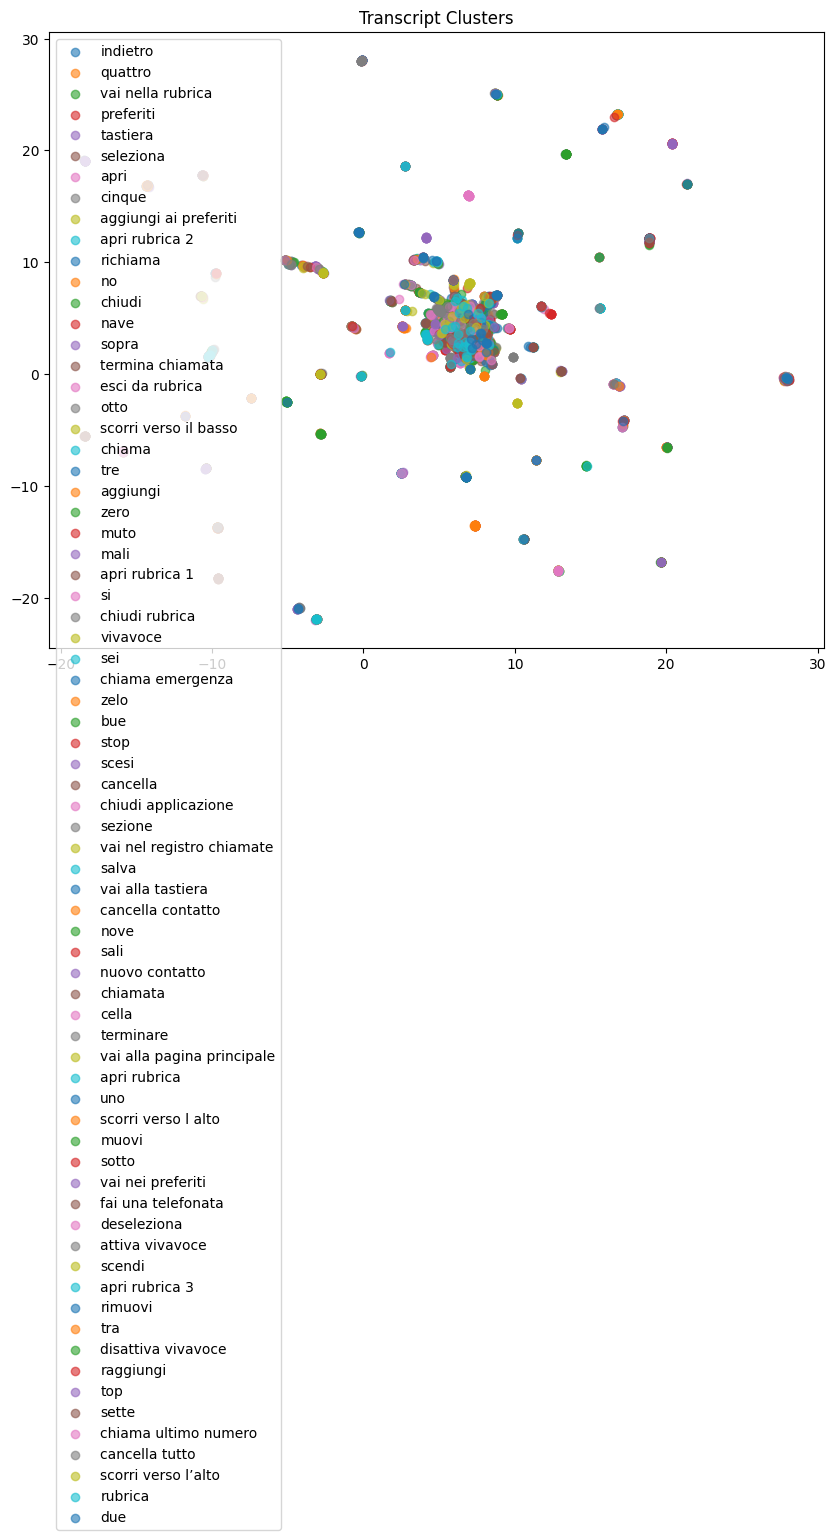

In [30]:
plt.figure(figsize=(10,8))

for cmd in set(labels):

    idx = [i for i,l in enumerate(labels) if l==cmd]

    plt.scatter(
        emb2d[idx,0],
        emb2d[idx,1],
        label=cmd,
        alpha=0.6
    )

plt.legend()
plt.title("Transcript Clusters")
plt.show()

Commands were selected based on three metrics derived from ASR outputs: transcript consistency, transcript entropy, and command separability in embedding space. The final ranking score combined these metrics to identify commands with stable and distinguishable ASR behavior.

In [49]:
import torch
torch.cuda.empty_cache()

In [31]:
for cmd in ["no","stop","quattro","nove","cinque","sei"]:
    print("\nCOMMAND:", cmd)
    print(Counter(command_transcripts[cmd]).most_common(10))


COMMAND: no
[('no', 25), ('grazie', 12), ('ciao', 4), ('la', 1), ('burbare', 1), ('markk', 1), ('allora', 1), ('grazie a tutti', 1), ('aaa', 1), ('i', 1)]

COMMAND: stop
[('stop', 10), ('ciao', 10), ('grazie', 7), ('stopp', 6), ('start', 3), ('ok', 2), ('grazie a tutti', 2), ('il termino', 1), ('a', 1), ('', 1)]

COMMAND: quattro
[('4', 12), ('grazie', 12), ('quattro', 11), ('grazie a tutti', 5), ('a presto', 2), ('sì', 1), ('ok', 1), ('adarrò', 1), ('quresso', 1), ('team', 1)]

COMMAND: nove
[('noi', 16), ('ciao', 6), ('no', 4), ('ciao a tutti', 2), ('novi', 2), ('no no', 2), ('wow', 2), ('no magari', 1), ('grazie', 1), ('no di', 1)]

COMMAND: cinque
[('grazie', 15), ('grazie a tutti', 7), ('5', 4), ('cinque', 2), ('cine', 1), ('sìinta', 1), ('cè un광o', 1), ('driving', 1), ('viva', 1), ('kinga', 1)]

COMMAND: sei
[('ciao', 25), ('hai', 4), ('sì', 3), ('oh', 3), ('ok', 3), ('grazie', 2), ('ho', 2), ('grazie a tutti', 1), ('è sempre gli armi e nessuno', 1), ('vai', 1)]


For the first prototype:

no
stop
quattro
nove
cinque

In [32]:
MVP_COMMANDS = [
    "no",
    "stop",
    "quattro",
    "nove",
    "cinque"
]

In [33]:
severity1 = ds["train"].filter(
    lambda x: x["dysarthria_severity"] == "1"
)

mvp_dataset = severity1.filter(
    lambda x: x["text"] in MVP_COMMANDS
)

Filter:   0%|          | 0/3588 [00:00<?, ? examples/s]

In [34]:
print(len(mvp_dataset))

265


In [35]:
mvp_dataset = mvp_dataset.remove_columns(
    [c for c in mvp_dataset.column_names if c not in ["audio","text"]]
)

In [36]:
#Convert commands to int labels
command2id = {
    cmd:i for i,cmd in enumerate(MVP_COMMANDS)
}

id2command = {
    i:cmd for cmd,i in command2id.items()
}

In [37]:
def add_label(example):
    example["label"] = command2id[example["text"]]
    return example

mvp_dataset = mvp_dataset.map(add_label)

Map:   0%|          | 0/265 [00:00<?, ? examples/s]

In [43]:
import datasets
mvp_dataset = mvp_dataset.cast_column(
    "audio",
    datasets.Audio(sampling_rate=16000)
)

In [44]:
print(mvp_dataset)

Dataset({
    features: ['audio', 'text', 'label'],
    num_rows: 265
})


In [47]:
for i in range(5):
    print(mvp_dataset[i])
    print()

{'audio': {'path': 'm04_01_Quattro.wav', 'array': array([4.51817687e-06, 8.94779077e-06, 1.22576075e-05, ...,
       1.55131053e-03, 1.28675508e-03, 6.05498673e-04], shape=(33920,)), 'sampling_rate': 16000}, 'text': 'quattro', 'label': 2}

{'audio': {'path': 'm04_01_No.wav', 'array': array([4.51817687e-06, 8.94779077e-06, 1.22576075e-05, ...,
       1.02830434e-03, 1.00912084e-03, 5.11446968e-04], shape=(24640,)), 'sampling_rate': 16000}, 'text': 'no', 'label': 0}

{'audio': {'path': 'm04_01_Nove.wav', 'array': array([ 4.51817687e-06,  8.94779077e-06,  1.22576075e-05, ...,
       -2.14425568e-03, -1.73056300e-03, -8.23068549e-04], shape=(30080,)), 'sampling_rate': 16000}, 'text': 'nove', 'label': 3}

{'audio': {'path': 'm04_01_Stop.wav', 'array': array([ 4.51817687e-06,  8.94779077e-06,  1.22576075e-05, ...,
       -1.49258587e-04, -1.95889384e-04, -1.08788518e-04], shape=(30720,)), 'sampling_rate': 16000}, 'text': 'stop', 'label': 1}

{'audio': {'path': 'm04_01_Cinque.wav', 'array': a

In [48]:
mvp_dataset.save_to_disk("easycall_mvp_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/265 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_from_disk

mvp_dataset = load_from_disk("easycall_mvp_dataset")